In [2]:
import pandas as pd
from pathlib import Path
import nibabel as nib
from pathlib import Path
import numpy as np
import itertools
from sklearn.metrics import jaccard_score, f1_score
import pandas as pd
from tqdm import trange
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from nilearn.image import resample_to_img, load_img

plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'Arial'

In [3]:
DATA_PATH = Path('../data')
RESULTS_PATH = Path('../results')
PLOTS_PATH = Path('../plots')

data_folder = RESULTS_PATH / 'nii'
PLOT_KWARGS_DICT = dict(bbox_inches='tight', transparent=True, dpi=600)

CBP_RESULTS_PATH = Path('../../Connectivity_Based_Parcellation/results')

In [4]:
def max_jaccard_score(y_true, y_pred, n):
    numbers = list(range(1, n + 1))
    scores = []
    for perm in itertools.permutations(numbers):
        correspondence = dict(zip(numbers, perm))
        new_y_pred = np.vectorize(correspondence.get)(y_pred)
        score = jaccard_score(y_true=y_true, y_pred=new_y_pred, average='macro')
        scores.append(score)
    return max(scores)


def max_dice_score(y_true, y_pred, n):
    numbers = list(range(1, n + 1))
    scores = []
    for perm in itertools.permutations(numbers):
        correspondence = dict(zip(numbers, perm))
        new_y_pred = np.vectorize(correspondence.get)(y_pred)
        score = f1_score(y_true, new_y_pred, average='macro')
        scores.append(score)
    return max(scores)


def set_upper_tri_nan(df):
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            if i < j:
                df.iloc[i, j] = np.nan
    return df

# Setup

In [12]:

k_list = list(range(2, 7))

MAPPING_DICT = {
    'Mye': [RESULTS_PATH / f'nii/Myelination_HCP_3T_K{k}.nii.gz' for k in k_list],
    # 'FC': [CBP_PATH / f'HCP_YA_age_22_35_resting_K{k}.nii.gz' for k in k_list],
    'SC': [CBP_RESULTS_PATH / f'nii/HCP_YA_age_22_35_DTI_K{k}.nii.gz' for k in k_list],
    'BEN': [RESULTS_PATH / f'nii/BEN_HCP_3T_K{k}.nii.gz' for k in k_list],
    'GMV': [RESULTS_PATH / f'nii/GMV_HCP_3T_K{k}.nii.gz' for k in k_list],
    'NR': [RESULTS_PATH / f'nii/Neurotransmitter_K{k}.nii.gz' for k in k_list],

}

In [13]:
for k in k_list:
    idx = k_list.index(k)
    name_file_mapping_dict = {k: v[idx] for k, v in MAPPING_DICT.items()}
    result = []
    for name_1, name_2 in itertools.combinations(name_file_mapping_dict.keys(), 2):
        file_1 = name_file_mapping_dict[name_1]
        file_2 = name_file_mapping_dict[name_2]

        data_1 = nib.load(file_1).get_fdata()
        data_2 = nib.load(file_2).get_fdata()

        mask_1 = data_1 > 0
        mask_2 = data_2 > 0
        shared_mask = mask_1 & mask_2

        data_1 = np.round(data_1)[shared_mask]
        data_2 = np.round(data_2)[shared_mask]

        score = max_dice_score(data_1, data_2, k)
        result.append(dict(name_1=name_1, name_2=name_2, score=score))
        result.append(dict(name_1=name_2, name_2=name_1, score=score))
    result = pd.DataFrame(result)
    result = result.pivot(index='name_1', columns='name_2', values='score')
    result = result.loc[list(MAPPING_DICT.keys()), list(MAPPING_DICT.keys())]
    result.to_csv(RESULTS_PATH / f'Dice_K{k}.csv')

K = 2, Mean Dice = 0.580 SD Dice = 0.139
K = 3, Mean Dice = 0.617 SD Dice = 0.088
K = 4, Mean Dice = 0.455 SD Dice = 0.057
K = 5, Mean Dice = 0.445 SD Dice = 0.058
K = 6, Mean Dice = 0.374 SD Dice = 0.060


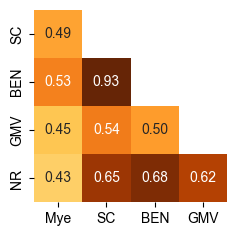

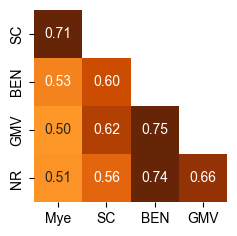

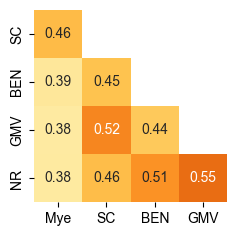

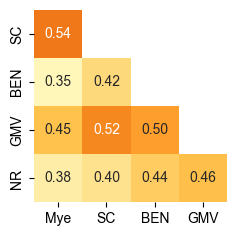

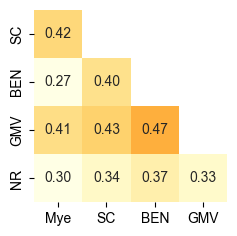

In [8]:
for cluster_n in range(2, 7):
    result = pd.read_csv(RESULTS_PATH / f'Dice_K{cluster_n}.csv', index_col=0)
    result = result.iloc[1:, :-1]
    result = set_upper_tri_nan(result)
    print(f'K = {cluster_n}, Mean Dice = {np.nanmean(result):.3f} SD Dice = {np.nanstd(result, ddof=0):.3f}')
    fig, ax = plt.subplots(figsize=(2.5, 2.5))
    sns.heatmap(result, annot=True, fmt='.2f', vmin=0.3, vmax=0.7,
                ax=ax, cbar=False, cmap='YlOrBr')
    ax.set_ylabel('')
    ax.set_xlabel('')
    fig.savefig(PLOTS_PATH / f'Dice_{cluster_n}.svg', **PLOT_KWARGS_DICT)

In [86]:
1

1